<div style="display:flex;align-items:center;justify-content:space-between;border-bottom:2px solid #c8962d;padding-bottom:12px;margin-bottom:20px">
  <div><strong>Universidad Externado de Colombia</strong><br>
  <span>Programa de Ciencia de Datos · Machine Learning II</span><br>
  <span>Docente: Wilmer Pineda-Ríos</span></div>
  <img src="../../assets/brand/logo-externado.png" width="190">
</div>

# Caso InmoValor — ¿a qué precio deberíamos publicar una vivienda?

**Semana curricular 4 · Gradient Boosting, XGBoost, LightGBM y CatBoost**

Usted es la persona propietaria de **InmoValor**, una inmobiliaria que capta viviendas en Ames, Iowa. Una mala valoración tiene dos costos:

- **sobrevalorar** puede alargar el tiempo en el mercado y deteriorar la confianza del propietario;
- **subvalorar** puede acelerar la venta, pero sacrificar valor y comisión.

La empresa no necesita solamente el modelo con el número más pequeño. Necesita una recomendación de precio **defendible**, saber cuándo desconfiar de ella y explicar qué características sostienen la predicción.

## Pregunta problema

> **¿Qué modelo debería adoptar InmoValor para recomendar el precio de salida de una vivienda, y qué características permiten explicar sus aciertos, errores y limitaciones?**

Para contestarla deberemos producir cuatro evidencias:

1. desempeño fuera de muestra frente a una regla simple;
2. estabilidad entre particiones y error en viviendas costosas;
3. análisis de sobrevaloraciones y subvaloraciones;
4. importancia de variables estimada sin reutilizar entrenamiento.

### Regla de interpretación

En cada resultado complete mentalmente: **observo → significa → recomendaría → no puedo concluir**.

## Protocolo acordado antes de modelar

- `SalePrice` es el precio observado de venta.
- MAE en dólares será la métrica principal porque se traduce en error típico para el negocio.
- RMSE mostrará sensibilidad a errores grandes.
- El 20 % de test permanecerá cerrado hasta seleccionar el modelo.
- Cinco folds comunes estimarán desempeño y estabilidad.
- Un modelo es candidato si reduce al menos 10 % el MAE del baseline; entre candidatos gana el menor MAE medio.
- La desviación entre folds y el MAE del cuartil costoso funcionan como alertas, no como criterios ocultos para cambiar al ganador.

**Antes de ejecutar:** ¿qué costo considera más grave para la inmobiliaria: sobrevalorar o subvalorar? ¿Cambiaría eso la métrica principal?

In [1]:
from pathlib import Path
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
import lightgbm
import catboost

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 3)

pd.Series({
    "Python": platform.python_version(),
    "scikit-learn": sklearn.__version__,
    "XGBoost": xgboost.__version__,
    "LightGBM": lightgbm.__version__,
    "CatBoost": catboost.__version__,
}, name="versión")

Python          3.14.3
scikit-learn     1.9.0
XGBoost          3.4.1
LightGBM         4.7.0
CatBoost        1.2.10
Name: versión, dtype: str

## 1. Conocer el inventario antes de prometer una valoración

Los datos describen ventas residenciales en Ames, Iowa. El archivo proviene del registro 42165 de OpenML y corresponde a la versión docente de Ames Housing compilada por De Cock (2011).

**Pregunta del propietario:** ¿la información disponible se conocería realmente antes de recomendar el precio de publicación?

In [2]:
candidates = [
    Path("../../datasets/public/Ames_Housing.csv"),
    Path("datasets/public/Ames_Housing.csv"),
    Path("../datasets/public/Ames_Housing.csv"),
]
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("No se encontró datasets/public/Ames_Housing.csv")

df = pd.read_csv(data_path)
target = "SalePrice"

pd.Series({
    "viviendas": len(df),
    "columnas": df.shape[1],
    "precio_mediano_USD": df[target].median(),
    "precio_mínimo_USD": df[target].min(),
    "precio_máximo_USD": df[target].max(),
    "celdas_faltantes_pct": 100 * df.isna().sum().sum() / df.size,
})

viviendas                 1460.00
columnas                    81.00
precio_mediano_USD      163000.00
precio_mínimo_USD        34900.00
precio_máximo_USD       755000.00
celdas_faltantes_pct         6.62
dtype: float64

In [3]:
audit = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "únicos": df.nunique(dropna=True),
})
audit.sort_values("faltantes", ascending=False).head(12)

,tipo,faltantes,únicos
PoolQC,str,1453,3
MiscFeature,str,1406,4
Alley,str,1369,2
Fence,str,1179,4
MasVnrType,str,872,3
FireplaceQu,str,690,5
LotFrontage,float64,259,110
GarageQual,str,81,5
GarageFinish,str,81,3
GarageType,str,81,6


### Auditoría interpretativa

Complete antes de seguir:

- **Observo:** ¿qué variables tienen más faltantes?
- **Significa:** ¿un faltante representa desconocimiento o ausencia física, como no tener piscina?
- **Recomendaría:** ¿imputar, crear una categoría de ausencia o descartar?
- **No puedo concluir:** que una vivienda sin dato sea necesariamente una vivienda sin esa característica.

`Id` identifica filas y se excluirá. No usaremos información creada después de la venta para simular una valoración futura.

## 2. Ingeniería de variables con una razón de negocio

No construiremos cientos de combinaciones a ciegas. Crearemos variables que una persona tasadora podría explicar:

| Variable nueva | Pregunta que resume |
|---|---|
| `AgeAtSale` | ¿Cuántos años tenía la vivienda al venderse? |
| `YearsSinceRemodel` | ¿Qué tan reciente era su última remodelación? |
| `TotalSF` | ¿Cuánta superficie interior útil reúne? |
| `TotalBathrooms` | ¿Cuántos baños equivalentes ofrece? |
| `TotalOutdoorSF` | ¿Cuánta superficie exterior aprovechable tiene? |
| `HasGarage`, `HasBasement` | ¿Dispone de estas amenidades? |

Todas se calculan fila a fila y no consultan el precio objetivo ni estadísticas del conjunto completo.

In [4]:
def engineer_features(frame):
    out = frame.copy()
    out["AgeAtSale"] = (out["YrSold"] - out["YearBuilt"]).clip(lower=0)
    out["YearsSinceRemodel"] = (out["YrSold"] - out["YearRemodAdd"]).clip(lower=0)
    out["TotalSF"] = out[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]].fillna(0).sum(axis=1)
    out["TotalBathrooms"] = (
        out[["FullBath", "BsmtFullBath"]].fillna(0).sum(axis=1)
        + 0.5 * out[["HalfBath", "BsmtHalfBath"]].fillna(0).sum(axis=1)
    )
    out["TotalOutdoorSF"] = out[
        ["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]
    ].fillna(0).sum(axis=1)
    out["HasGarage"] = np.where(out["GarageArea"].fillna(0).gt(0), "Sí", "No")
    out["HasBasement"] = np.where(out["TotalBsmtSF"].fillna(0).gt(0), "Sí", "No")
    out["MSSubClass"] = out["MSSubClass"].astype(str)
    return out

X_raw = df.drop(columns=[target, "Id"])
X = engineer_features(X_raw)
y = df[target].astype(float)
ENGINEERED = [
    "AgeAtSale", "YearsSinceRemodel", "TotalSF", "TotalBathrooms",
    "TotalOutdoorSF", "HasGarage", "HasBasement",
]

X[ENGINEERED].head()

,AgeAtSale,YearsSinceRemodel,TotalSF,TotalBathrooms,TotalOutdoorSF,HasGarage,HasBasement
0,5,5,2566,3.5,61,Sí,Sí
1,31,31,2524,2.5,298,Sí,Sí
2,7,6,2706,3.5,42,Sí,Sí
3,91,36,2473,2.0,307,Sí,Sí
4,8,8,3343,3.5,276,Sí,Sí


### Prueba de criterio

1. ¿Cuál variable nueva tendría la explicación más clara para un propietario?
2. ¿Cuál puede ser redundante con sus componentes originales?
3. ¿Por qué `AgeAtSale` es preferible a interpretar `YearBuilt` aislado?
4. ¿Qué variable construiría usted y qué decisión ayudaría a tomar?

In [5]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
X_raw_dev = X_raw.loc[X_dev.index]
X_raw_test = X_raw.loc[X_test.index]
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pd.Series({
    "desarrollo_n": len(X_dev),
    "test_n": len(X_test),
    "precio_mediano_desarrollo": y_dev.median(),
    "precio_mediano_test": y_test.median(),
    "umbral_cuartil_costoso": y_dev.quantile(0.75),
})

desarrollo_n                   1168.0
test_n                          292.0
precio_mediano_desarrollo    165000.0
precio_mediano_test          154150.0
umbral_cuartil_costoso       214925.0
dtype: float64

## 3. ¿Cómo aprende Gradient Boosting?

La primera predicción puede ser una constante. Cada árbol posterior intenta explicar el error que dejó la suma anterior:

\[
F_m(x)=F_{m-1}(x)+\eta h_m(x).
\]

Si una vivienda vale 200 mil y el modelo actual predice 170 mil, el residual positivo pide corregir hacia arriba. `learning_rate` controla cuánto confiamos en cada corrección.

**Prediga antes de ejecutar:** ¿qué ocurrirá con error de entrenamiento y validación al agregar demasiados árboles?

In [6]:
toy = pd.DataFrame({
    "vivienda": ["A", "B", "C", "D"],
    "precio_real": [120_000, 160_000, 210_000, 310_000],
})
toy["predicción_inicial"] = toy["precio_real"].mean()
toy["residual_1"] = toy["precio_real"] - toy["predicción_inicial"]
toy["corrección_árbol"] = [-55_000, -25_000, 20_000, 60_000]
toy["predicción_con_eta_0.5"] = toy["predicción_inicial"] + 0.5 * toy["corrección_árbol"]
toy["residual_2"] = toy["precio_real"] - toy["predicción_con_eta_0.5"]
toy

,vivienda,precio_real,predicción_inicial,residual_1,corrección_árbol,predicción_con_eta_0.5,residual_2
0,A,120000,200000.0,-80000.0,-55000,172500.0,-52500.0
1,B,160000,200000.0,-40000.0,-25000,187500.0,-27500.0
2,C,210000,200000.0,10000.0,20000,210000.0,0.0
3,D,310000,200000.0,110000.0,60000,230000.0,80000.0


In [7]:
def make_preprocessor(frame):
    categorical = frame.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric = [column for column in frame.columns if column not in categorical]
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False)),
        ]), categorical),
    ], verbose_feature_names_out=False)

def wrap_model(model, frame):
    pipeline = Pipeline([
        ("prepare", make_preprocessor(frame)),
        ("model", model),
    ])
    return TransformedTargetRegressor(
        regressor=pipeline, func=np.log1p, inverse_func=np.expm1
    )

gb_params = dict(
    n_estimators=250, learning_rate=0.04, max_depth=2,
    min_samples_leaf=8, loss="huber", random_state=RANDOM_STATE,
)

## 4. ¿La ingeniería de variables aporta evidencia?

La comparación mantiene modelo, folds y métrica. Solo cambia la representación. Así evitamos atribuirle al algoritmo una mejora producida por información distinta.

In [8]:
gb_raw = wrap_model(GradientBoostingRegressor(**gb_params), X_raw_dev)
gb_engineered = wrap_model(GradientBoostingRegressor(**gb_params), X_dev)
mae_scorer = "neg_mean_absolute_error"

feature_experiment = []
for representation, estimator, frame in [
    ("Variables originales", gb_raw, X_raw_dev),
    ("Originales + ingeniería", gb_engineered, X_dev),
]:
    scores = -cross_validate(
        estimator, frame, y_dev, cv=cv, scoring=mae_scorer, n_jobs=1
    )["test_score"]
    feature_experiment.append({
        "representación": representation,
        "MAE_medio_USD": scores.mean(),
        "MAE_sd_USD": scores.std(ddof=1),
    })

feature_results = pd.DataFrame(feature_experiment).set_index("representación")
feature_results.assign(
    mejora_vs_original_pct=lambda table: 100 * (
        feature_results.iloc[0, 0] - table["MAE_medio_USD"]
    ) / feature_results.iloc[0, 0]
)

C:\Users\legion\AppData\Local\Temp\ipykernel_24172\274134315.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = frame.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\legion\AppData\Local\Temp\ipykernel_24172\274134315.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas

,MAE_medio_USD,MAE_sd_USD,mejora_vs_original_pct
representación,,,
Variables originales,16564.612,1457.599,0.000
Originales + ingeniería,16093.301,1212.291,2.845


### Interpretación obligatoria

- **Observo:** ¿cuántos dólares cambia el MAE y cuánto representa porcentualmente?
- **Significa:** ¿la mejora es grande frente al precio típico y a la variación entre folds?
- **Recomendaría:** ¿mantener estas variables en producción?
- **No puedo concluir:** que aumentar una de ellas causaría exactamente el cambio observado en precio.

## 5. Selección del modelo como decisión empresarial

Todos los candidatos reciben la misma matriz preparada y la misma transformación logarítmica del objetivo. Esto hace comparable la prueba principal. Más adelante discutiremos que CatBoost también puede trabajar con categorías nativas.

La tabla responderá:

- ¿cuántos dólares se equivoca normalmente cada modelo?;
- ¿qué tan variable es ese error entre folds?;
- ¿cómo cambia en el 25 % de viviendas más costosas?;
- ¿cuánto mejora frente a publicar siempre el precio mediano?

In [9]:
HIGH_PRICE_THRESHOLD = y_dev.quantile(0.75)

def high_price_mae(y_true, y_pred):
    truth = np.asarray(y_true)
    prediction = np.asarray(y_pred)
    mask = truth >= HIGH_PRICE_THRESHOLD
    return mean_absolute_error(truth[mask], prediction[mask])

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "mae_costosas": make_scorer(high_price_mae, greater_is_better=False),
}

models = {
    "Baseline mediana": DummyRegressor(strategy="median"),
    "Gradient Boosting": GradientBoostingRegressor(**gb_params),
    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.035, max_depth=3,
        min_child_weight=3, subsample=0.85, colsample_bytree=0.85,
        reg_lambda=2.0, objective="reg:squarederror",
        random_state=RANDOM_STATE, n_jobs=2,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=400, learning_rate=0.035, num_leaves=15,
        max_depth=5, min_child_samples=20, subsample=0.85,
        colsample_bytree=0.85, reg_lambda=2.0,
        random_state=RANDOM_STATE, n_jobs=2, verbosity=-1,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=400, learning_rate=0.035, depth=5,
        l2_leaf_reg=4.0, loss_function="RMSE",
        random_seed=RANDOM_STATE, verbose=False,
        allow_writing_files=False, thread_count=2,
    ),
}

estimators = {name: wrap_model(model, X_dev) for name, model in models.items()}

C:\Users\legion\AppData\Local\Temp\ipykernel_24172\274134315.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = frame.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\legion\AppData\Local\Temp\ipykernel_24172\274134315.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas

In [10]:
fold_rows = []
for name, estimator in estimators.items():
    result = cross_validate(
        estimator, X_dev, y_dev, cv=cv, scoring=scoring,
        n_jobs=1, error_score="raise",
    )
    for fold in range(cv.get_n_splits()):
        fold_rows.append({
            "modelo": name,
            "fold": fold + 1,
            "MAE_USD": -result["test_mae"][fold],
            "RMSE_USD": -result["test_rmse"][fold],
            "MAE_costosas_USD": -result["test_mae_costosas"][fold],
        })

fold_results = pd.DataFrame(fold_rows)
cv_results = fold_results.groupby("modelo").agg(
    MAE_medio_USD=("MAE_USD", "mean"),
    MAE_sd_USD=("MAE_USD", "std"),
    RMSE_medio_USD=("RMSE_USD", "mean"),
    MAE_costosas_USD=("MAE_costosas_USD", "mean"),
).sort_values("MAE_medio_USD")

baseline_mae = cv_results.loc["Baseline mediana", "MAE_medio_USD"]
cv_results["mejora_vs_baseline_pct"] = 100 * (
    baseline_mae - cv_results["MAE_medio_USD"]
) / baseline_mae
cv_results

,MAE_medio_USD,MAE_sd_USD,RMSE_medio_USD,MAE_costosas_USD,mejora_vs_baseline_pct
modelo,,,,,
CatBoost,14785.132,980.983,26244.313,25733.134,72.914
XGBoost,15230.639,953.107,26476.614,27133.837,72.098
LightGBM,15362.738,919.983,26343.721,27298.036,71.856
Gradient Boosting,16093.301,1212.291,28160.396,28401.031,70.518
Baseline mediana,54586.125,2992.478,78860.115,120987.796,0.000


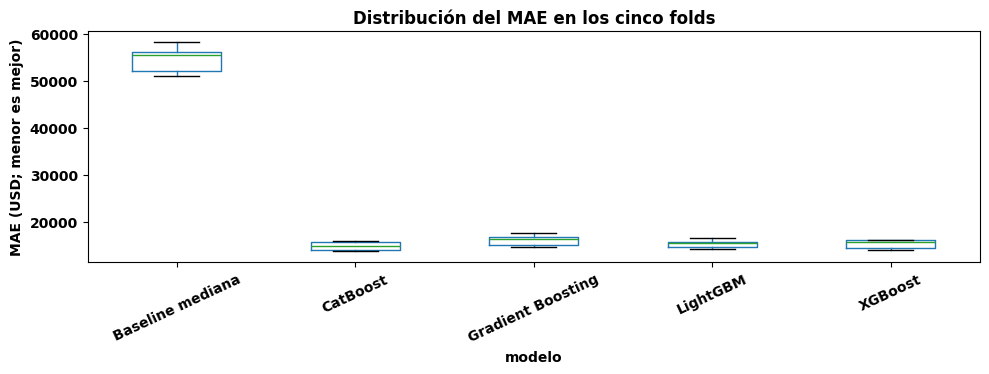

In [11]:
ax = fold_results.boxplot(column="MAE_USD", by="modelo", figsize=(10, 4), grid=False)
plt.suptitle("")
ax.set_title("Distribución del MAE en los cinco folds")
ax.set_ylabel("MAE (USD; menor es mejor)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Comité de selección

Antes de revelar test, redacte una recomendación de cuatro líneas:

1. modelo que escogería;
2. evidencia de MAE y mejora frente al baseline;
3. alerta de estabilidad o segmento costoso;
4. razón por la que todavía no debe mirar test.

In [12]:
eligible = cv_results[cv_results["mejora_vs_baseline_pct"] >= 10]
if eligible.empty:
    raise RuntimeError("Ningún modelo supera el umbral empresarial del 10 %.")

selected_name = eligible["MAE_medio_USD"].idxmin()
selected_estimator = clone(estimators[selected_name])

pd.Series({
    "modelo_seleccionado": selected_name,
    "regla": "menor MAE medio entre modelos que mejoran al baseline >= 10 %",
    "MAE_CV_USD": cv_results.loc[selected_name, "MAE_medio_USD"],
    "MAE_sd_USD": cv_results.loc[selected_name, "MAE_sd_USD"],
    "mejora_vs_baseline_pct": cv_results.loc[selected_name, "mejora_vs_baseline_pct"],
})

modelo_seleccionado                                                CatBoost
regla                     menor MAE medio entre modelos que mejoran al b...
MAE_CV_USD                                                        14785.132
MAE_sd_USD                                                          980.983
mejora_vs_baseline_pct                                               72.914
dtype: object

## 6. Abrir test una sola vez

La selección ya está congelada. Test no decidirá qué modelo nos gusta; estimará cómo funcionaría la decisión acordada frente a viviendas no usadas en desarrollo.

In [13]:
selected_estimator.fit(X_dev, y_dev)
test_prediction = np.maximum(selected_estimator.predict(X_test), 0)
test_residual = y_test.to_numpy() - test_prediction

test_metrics = pd.Series({
    "modelo": selected_name,
    "MAE_USD": mean_absolute_error(y_test, test_prediction),
    "RMSE_USD": mean_squared_error(y_test, test_prediction) ** 0.5,
    "sesgo_medio_real_menos_predicho_USD": test_residual.mean(),
    "subvaloraciones_n": int((test_prediction < y_test.to_numpy()).sum()),
    "sobrevaloraciones_n": int((test_prediction > y_test.to_numpy()).sum()),
})
test_metrics

modelo                                  CatBoost
MAE_USD                                15264.103
RMSE_USD                               28295.748
sesgo_medio_real_menos_predicho_USD     2732.472
subvaloraciones_n                            156
sobrevaloraciones_n                          136
dtype: object

In [14]:
q25, q75 = y_dev.quantile([0.25, 0.75])
segments = pd.cut(
    y_test, bins=[-np.inf, q25, q75, np.inf],
    labels=["Económica", "Intermedia", "Costosa"],
)
error_table = pd.DataFrame({
    "precio_real": y_test,
    "predicción": test_prediction,
    "error": test_residual,
    "error_absoluto": np.abs(test_residual),
    "segmento": segments,
})
segment_results = error_table.groupby("segmento", observed=True).agg(
    viviendas=("precio_real", "size"),
    precio_mediano=("precio_real", "median"),
    MAE_USD=("error_absoluto", "mean"),
    sesgo_real_menos_predicho=("error", "mean"),
)
segment_results

,viviendas,precio_mediano,MAE_USD,sesgo_real_menos_predicho
segmento,,,,
Económica,83,109500.0,8793.825,-4682.725
Intermedia,141,155900.0,10629.589,770.434
Costosa,68,275500.0,32771.447,15851.717


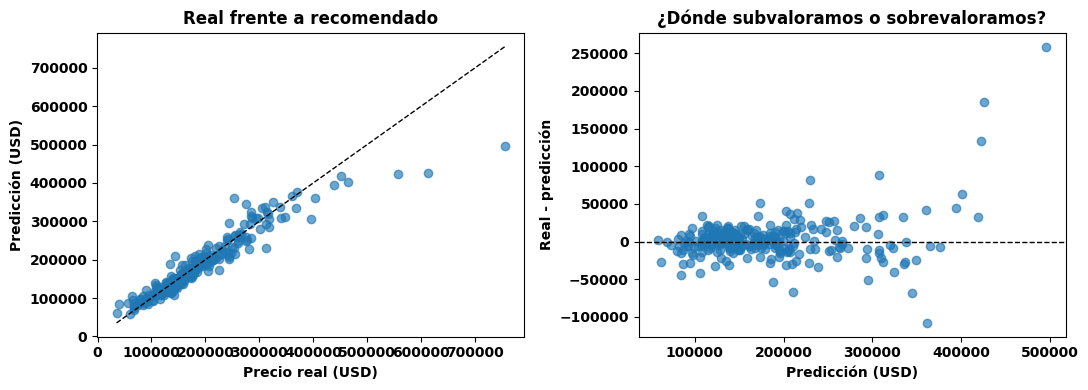

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, test_prediction, alpha=0.65)
limits = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
axes[0].plot(limits, limits, "--", color="black", linewidth=1)
axes[0].set(xlabel="Precio real (USD)", ylabel="Predicción (USD)", title="Real frente a recomendado")

axes[1].scatter(test_prediction, test_residual, alpha=0.65)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(xlabel="Predicción (USD)", ylabel="Real - predicción", title="¿Dónde subvaloramos o sobrevaloramos?")
plt.tight_layout()
plt.show()

### Lectura empresarial de los errores

- Residual positivo: el modelo recomendó menos que el precio observado; riesgo de **subvaloración**.
- Residual negativo: recomendó más; riesgo de **sobrevaloración**.

Conteste:

1. ¿En qué segmento confiaría menos y con qué evidencia?
2. ¿Existe sesgo sistemático o errores grandes en ambos sentidos?
3. ¿El MAE general oculta un problema importante?
4. ¿Qué revisión humana activaría antes de publicar una vivienda costosa?

## 7. Feature importance: ¿qué información sostiene la predicción?

Calcularemos **importancia por permutación en test**, después de seleccionar y ajustar el modelo. La caída del desempeño responde: “¿cuánto empeora el MAE al romper la información de esta variable?”.

Ventajas para InmoValor:

- conserva las columnas en lenguaje de negocio;
- está ligada al desempeño fuera de muestra;
- permite comparar variables originales y construidas.

Limitaciones: variables correlacionadas pueden sustituirse y repartir su importancia; el resultado no entrega dirección del efecto ni causalidad.

In [16]:
permutation = permutation_importance(
    selected_estimator, X_test, y_test,
    scoring="neg_mean_absolute_error", n_repeats=12,
    random_state=RANDOM_STATE, n_jobs=1,
)
importance = pd.DataFrame({
    "variable": X_test.columns,
    "aumento_MAE_USD": permutation.importances_mean,
    "sd_USD": permutation.importances_std,
}).sort_values("aumento_MAE_USD", ascending=False)
importance.head(15)

,variable,aumento_MAE_USD,sd_USD
81,TotalSF,15355.451,764.245
16,OverallQual,9429.897,557.052
45,GrLivArea,1828.518,235.183
17,OverallCond,1579.168,260.904
82,TotalBathrooms,1184.897,294.648
3,LotArea,1125.530,218.415
60,GarageCars,1020.852,167.579
18,YearBuilt,851.040,133.489
55,Fireplaces,796.882,190.637
80,YearsSinceRemodel,689.160,166.298


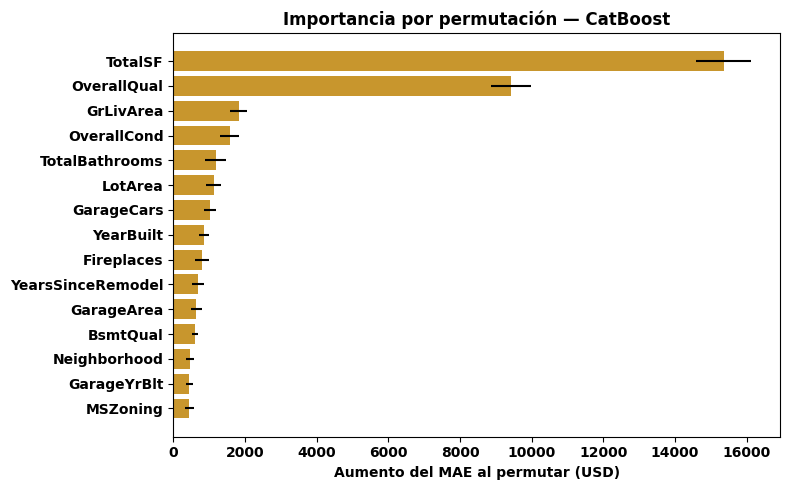

In [17]:
top = importance.head(15).sort_values("aumento_MAE_USD")
plt.figure(figsize=(8, 5))
plt.barh(top["variable"], top["aumento_MAE_USD"], xerr=top["sd_USD"], color="#c8962d")
plt.xlabel("Aumento del MAE al permutar (USD)")
plt.title(f"Importancia por permutación — {selected_name}")
plt.tight_layout()
plt.show()

### Contraste con la importancia incorporada

Los boosters también asignan importancia a las columnas transformadas. Ese ranking describe el uso interno del modelo y puede fragmentar una variable categórica en muchas categorías. Lo contrastamos con permutación, pero no buscamos forzar rankings idénticos.

In [18]:
fitted_pipeline = selected_estimator.regressor_
prepared_names = fitted_pipeline.named_steps["prepare"].get_feature_names_out()
fitted_booster = fitted_pipeline.named_steps["model"]

if hasattr(fitted_booster, "feature_importances_"):
    internal_importance = pd.DataFrame({
        "variable_transformada": prepared_names,
        "importancia_interna": fitted_booster.feature_importances_,
    }).sort_values("importancia_interna", ascending=False).head(15)
else:
    internal_importance = pd.DataFrame({
        "mensaje": ["El modelo seleccionado no expone feature_importances_."]
    })
internal_importance

,variable_transformada,importancia_interna
37,TotalSF,24.875
2,OverallQual,17.503
14,GrLivArea,4.726
4,YearBuilt,3.781
38,TotalBathrooms,3.208
22,Fireplaces,3.148
24,GarageCars,2.930
1,LotArea,2.785
3,OverallCond,2.604
36,YearsSinceRemodel,2.338


### Interpretar importancia sin vender causalidad

Para las cinco variables principales, complete:

| Variable | Evidencia predictiva | Uso posible | Riesgo de interpretación |
|---|---|---|---|
| … | el MAE aumenta al permutar | solicitar/verificar el dato | no conocemos dirección ni efecto causal |

Preguntas del dueño:

1. ¿Aparece alguna variable construida entre las principales?
2. ¿Qué variable esperaba ver y no aparece? ¿Podría estar correlacionada con otra?
3. ¿Qué dato sería prioritario verificar durante la captación?
4. ¿Puede concluirse que remodelar una casa elevará su precio en una cantidad específica? Explique.

## 8. Convertir una predicción en recomendación

Usaremos una vivienda de test como simulación. El rango `predicción ± MAE de CV` es una **banda operativa de conversación**, no un intervalo estadístico de confianza.

In [19]:
example_index = error_table["error_absoluto"].sort_values().index[len(error_table) // 2]
example_prediction = float(selected_estimator.predict(X_test.loc[[example_index]])[0])
operational_mae = float(cv_results.loc[selected_name, "MAE_medio_USD"])

pd.Series({
    "vivienda_Id": int(df.loc[example_index, "Id"]),
    "precio_recomendado_USD": round(example_prediction, -2),
    "banda_operativa_inferior": round(max(0, example_prediction - operational_mae), -2),
    "banda_operativa_superior": round(example_prediction + operational_mae, -2),
    "precio_observado_solo_para_evaluación": y_test.loc[example_index],
})

vivienda_Id                                 837.0
precio_recomendado_USD                   144500.0
banda_operativa_inferior                 129700.0
banda_operativa_superior                 159300.0
precio_observado_solo_para_evaluación    153500.0
dtype: float64

## 9. Respuesta final a la pregunta problema

Redacte como propietario de InmoValor, en máximo ocho líneas:

1. **Decisión:** modelo que adoptaría y para qué uso concreto.
2. **Evidencia:** MAE de CV, estabilidad, mejora frente al baseline y resultado de test.
3. **Segmento de riesgo:** dónde requiere revisión humana.
4. **Variables:** dos características predictivamente importantes y cómo verificaría su calidad.
5. **Limitación:** la importancia no demuestra causalidad y la banda propuesta no es un intervalo de confianza.

> Una buena respuesta no dice solamente “gana X”. Explica por qué la inmobiliaria puede usarlo, cuándo debe desconfiar y qué evidencia respalda la recomendación.

## Reto guiado por equipos — Comité de valoración

Sin entrega calificable, cada equipo dispone de 20 minutos:

1. escoger una vivienda entre los diez mayores errores;
2. describir si fue sobrevalorada o subvalorada;
3. revisar sus cinco variables más relevantes dentro del contexto del ranking global;
4. proponer una verificación humana adicional;
5. defender en 90 segundos si el modelo debe publicar un precio automáticamente o funcionar como apoyo.

### Ticket de salida

- Una razón técnica para elegir el modelo.
- Una razón empresarial para no automatizar totalmente la decisión.
- Una afirmación sobre feature importance que sería incorrecta.